# On fruit dataset

In [11]:
from sklearn.tree            import DecisionTreeClassifier
from sklearn.preprocessing    import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import tree
%matplotlib inline

In [12]:
df = pd.read_excel("data_fruit_type.xlsx")

In [13]:
print(df.head())

   weight      shape sweet   is_banana
0     0.1      round     y  Not banana
1     0.2      round     y  Not banana
2     0.2      round     n  Not banana
3     0.2      round     y  Not banana
4     0.4  elongated     y      Banana


In [14]:
# Separate features(X) and labels(y):
X = df[["weight", "shape", "sweet"]]
y = df["is_banana"]

In [15]:
print("X:\n", X)
print("y:\n", y)

X:
    weight      shape sweet
0     0.1      round     y
1     0.2      round     y
2     0.2      round     n
3     0.2      round     y
4     0.4  elongated     y
5     0.6  elongated     n
6     0.1  elongated     y
7     0.6      round     n
8     0.4  elongated     n
9     0.5  elongated     n
y:
 0    Not banana
1    Not banana
2    Not banana
3    Not banana
4        Banana
5        Banana
6        Banana
7    Not banana
8        Banana
9        Banana
Name: is_banana, dtype: object


In [16]:
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

In [17]:
# Create a copy so original data is safe. Encode shape and sweet.
X_encoded = X.copy()

le_shape = LabelEncoder()
le_sweet = LabelEncoder()

X_encoded["shape"] = le_shape.fit_transform(X["shape"])
X_encoded["sweet"] = le_sweet.fit_transform(X["sweet"])

In [18]:
print(X_encoded)

# print("Encoded labels:", y_encoded[:10])
print("Classes (shape):", le_shape.classes_)
print("Labels (shape) :", le_shape.transform(le_shape.classes_))

print("Classes (sweet):", le_sweet.classes_)
print("Labels (sweet) :", le_sweet.transform(le_sweet.classes_))

   weight  shape  sweet
0     0.1      1      1
1     0.2      1      1
2     0.2      1      0
3     0.2      1      1
4     0.4      0      1
5     0.6      0      0
6     0.1      0      1
7     0.6      1      0
8     0.4      0      0
9     0.5      0      0
Classes (shape): ['elongated' 'round']
Labels (shape) : [0 1]
Classes (sweet): ['n' 'y']
Labels (sweet) : [0 1]


In [19]:
# Since I am constructing a DT, so I do not need testing data.
X_train, y_train = X_encoded, y_encoded

In [20]:
# max_depth: The length of the longest path from a root node to a leaf node will not exceed this value.
# This is the most commonly tuned hyperparameter for tree-based method. Here I will uses default value
# model = DecisionTreeClassifier(max_depth = 2, # Try to change this to 3 and 4 and accuracy would go , but may be overfiting. 
#                              random_state = 0)

model = DecisionTreeClassifier(criterion="entropy") # or use this for entropy

In [21]:
# train the model
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [22]:
# Lets print all hyperparam
print(model.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


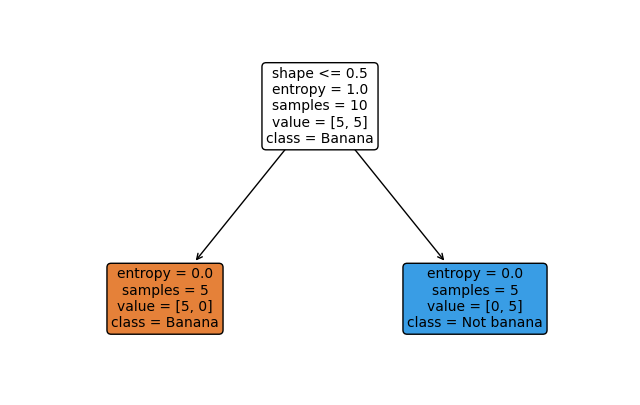

In [23]:
plt.figure(figsize=(8, 5))
tree.plot_tree(
    model,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=le_y.classes_,
    fontsize=10
)

plt.show()
# fig.savefig('plottreefncn.png') # optional if u want to save 

# NOTE: shape <= 0.5 translates to --> is the shape elongated. If yes, go left else go right. 

### or just display

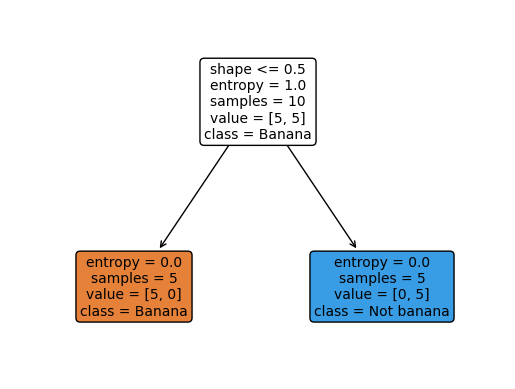

In [24]:
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing    import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("data_fruit_type.xlsx")
X = df[["weight", "shape", "sweet"]]
y = df["is_banana"]
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

X_encoded = X.copy()
le_shape = LabelEncoder()
le_sweet = LabelEncoder()
X_encoded["shape"] = le_shape.fit_transform(X["shape"])
X_encoded["sweet"] = le_sweet.fit_transform(X["sweet"])

X_train, y_train = X_encoded, y_encoded
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

plot_tree( model,filled=True, rounded=True, feature_names=X.columns,
               class_names=le_y.classes_, fontsize=10)
plt.show()

# On weather dataset
- This would give binary split because we are using label encoder

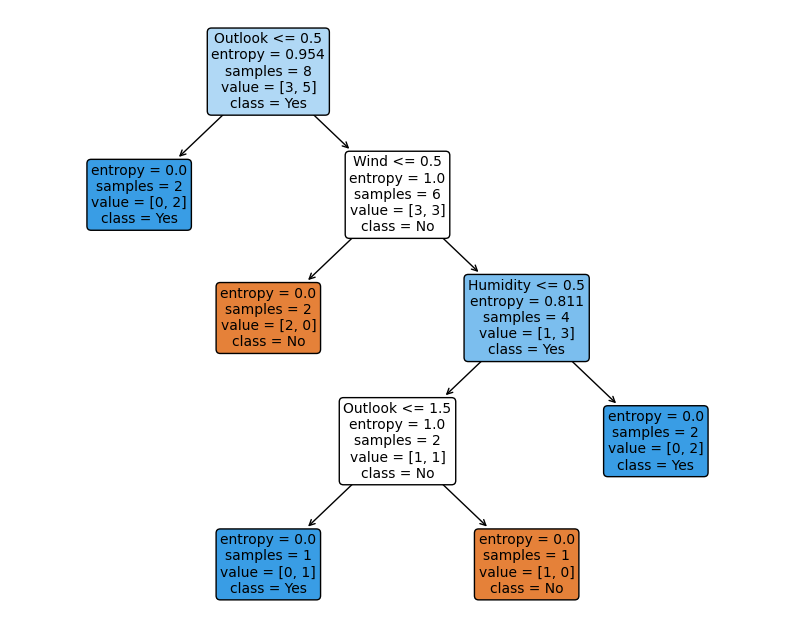

In [33]:
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing    import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("data_weather.xlsx")
X = df[["Outlook", "Humidity", "Wind"]]
y = df["Play"]
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

X_encoded   = X.copy()
le_outlook  = LabelEncoder()
le_humidity = LabelEncoder()
le_wind     = LabelEncoder()

X_encoded["Outlook"]  = le_outlook.fit_transform(X["Outlook"])
X_encoded["Humidity"] = le_humidity.fit_transform(X["Humidity"])
X_encoded["Wind"]     = le_wind.fit_transform(X["Wind"])

X_train, y_train = X_encoded, y_encoded
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

plt.figure(figsize=(10, 8))
plot_tree( model,filled=True, rounded=True, feature_names=X.columns,
               class_names=le_y.classes_, fontsize=10)
plt.show()

In [28]:
print(df)

   ID   Outlook Humidity    Wind Play
0   1     Sunny     High    Weak   No
1   2     Sunny     High  Strong   No
2   3  Overcast     High    Weak  Yes
3   4      Rain     High    Weak  Yes
4   5      Rain   Normal    Weak  Yes
5   6      Rain   Normal  Strong   No
6   7  Overcast   Normal  Strong  Yes
7   8     Sunny   Normal    Weak  Yes
